In [ ]:
import numpy as np
import umap
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_5.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_5.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model.fit(_embeddings)

d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.1
,spread,1.0


In [2]:
# Generate and evaluate multiple tracks plus mutated variants
import requests
import random
import copy

randomizer = random.Random(100)
num_tracks = 10
seed_candidates = randomizer.sample(range(1, 10000), num_tracks)

def generate_track(seed, randomizer):
    response = requests.post(
        "http://localhost:4242/generate",
        json={
            "id": seed,
            "mode": "voronoi",
            "trackSize": randomizer.randint(4, 10),
            "rngMode": 0,
        },
        timeout=60,
    )

    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    sol = response.json()
    sol["rngMode"] = 1
    return sol

def mutate_track(sol_in, intensity, randomizer):
    # deep copy sol
    sol = copy.deepcopy(sol_in)

    seed = sol["id"]
    response = requests.post(
                    f"http://localhost:4242/mutate",
                    json={
                        "individual": sol,
                        "intensityMutation": intensity, # Constant mutation intensity
                        "genetic_seed": seed
                    },
                    timeout=60
                )
    if not response.ok:
                    raise Exception(f"API error {response.status_code}: {response.text}")
    mutated = response.json().get("mutated", {})
    print("Mutated track keys:", mutated.keys())
    
    # Assign a unique, iteration-based ID for tracking
    sol["dataSet"] = mutated["dataSet"]
    # mutated["mode"] = sol.get("mode", "voronoi")
    sol["selectedCells"] = mutated["selectedCells"]
    return sol       

def eval_track(sol, get_traces=False):
    payload = dict(sol)
    if get_traces:
        payload["getTraces"] = True
    response = requests.post(
        "http://localhost:4242/evaluate",
        json=payload,
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    fit = r_json.get("fitness", {}) or {}
    trace_data = {}
    if get_traces:
        trace_data = {
            "speed_trace": fit.get("speed_trace", None),
            "steer_trace": fit.get("steer_trace", None),
            "brake_trace": fit.get("brake_trace", None),
            "accel_trace": fit.get("accel_trace", None),
            "border_dist_trace": fit.get("border_dist_trace", None),
        }
    return fit, trace_data

def reconstruct_track(sol):
    response = requests.post(
        "http://localhost:4242/reconstruct",
        json={
            "mode": sol.get("mode", "voronoi"),
            "seed": sol["id"],
            "dataSet": sol["dataSet"],
            "selectedCells": sol["selectedCells"],
            "trackSize": sol["trackSize"]
        },
        timeout=60,
    )
    if not response.ok:
        raise Exception(f"API error {response.status_code}: {response.text}")

    r_json = response.json()
    return r_json.get("track", None)

seeds = seed_candidates[:3]
intensities = [2, 10, 50, 70, 100, 500]

results_by_seed = {}
for seed in seeds:
    try:
        sol = generate_track(seed, randomizer)
    except Exception as exc:
        print(f"Seed {seed}: generate failed -> {exc}")
        continue
    print(f"Generated track keys for seed {seed}:", sol.keys())

    try:
        original_fit, original_traces = eval_track(sol, get_traces=True)
        original_embedding_data = original_fit.get("embedding_data", [])
    except Exception as exc:
        print(f"Seed {seed}: eval failed -> {exc}")
        continue

    try:
        original_track = reconstruct_track(sol)
    except Exception as exc:
        print(f"Seed {seed}: reconstruct failed -> {exc}")
        original_track = None

    mutated_embedding_data_by_intensity = {}
    mutated_traces_by_intensity = {}
    mutated_tracks_by_intensity = {}
    for intensity in intensities:
        try:
            mutated = mutate_track(sol, intensity=intensity, randomizer=randomizer)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: mutate failed -> {exc}")
            continue
        try:
            mutated_fit, mutated_traces = eval_track(mutated, get_traces=True)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: eval failed -> {exc}")
            continue
        mutated_embedding_data_by_intensity[intensity] = mutated_fit.get("embedding_data", [])
        mutated_traces_by_intensity[intensity] = mutated_traces
        try:
            mutated_tracks_by_intensity[intensity] = reconstruct_track(mutated)
        except Exception as exc:
            print(f"Seed {seed} intensity {intensity}: reconstruct failed -> {exc}")
            mutated_tracks_by_intensity[intensity] = None

    results_by_seed[seed] = {
        "intensities": intensities,
        "original_embedding_data": original_embedding_data,
        "original_traces": original_traces,
        "original_track": original_track,
        "mutated_embedding_data_by_intensity": mutated_embedding_data_by_intensity,
        "mutated_traces_by_intensity": mutated_traces_by_intensity,
        "mutated_tracks_by_intensity": mutated_tracks_by_intensity,
    }

Generated track keys for seed 2387: dict_keys(['id', 'mode', 'dataSet', 'selectedCells', 'trackSize', 'splineVector', 'rngMode'])
Seed 2387: eval failed -> API error 500: {"error":"ENOENT: no such file or directory, unlink 'C:\\Users\\milob\\AppData\\Local\\Temp\\2387.xml'"}
Generated track keys for seed 7529: dict_keys(['id', 'mode', 'dataSet', 'selectedCells', 'trackSize', 'splineVector', 'rngMode'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Seed 7529 intensity 2: eval failed -> API error 500: {"error":"ENOENT: no such file or directory, unlink 'C:\\Users\\milob\\AppData\\Local\\Temp\\7529.xml'"}
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Mutated track keys: dict_keys(['dataSet', 'selectedCells'])
Generated track keys for seed 7454: dict_keys(['id', 'mode', 'dataSet', 'sel

Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_4.pth...
Model loaded with latent_dim=32


C:\Users\milob\AppData\Local\Temp\ipykernel_24284\931951594.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


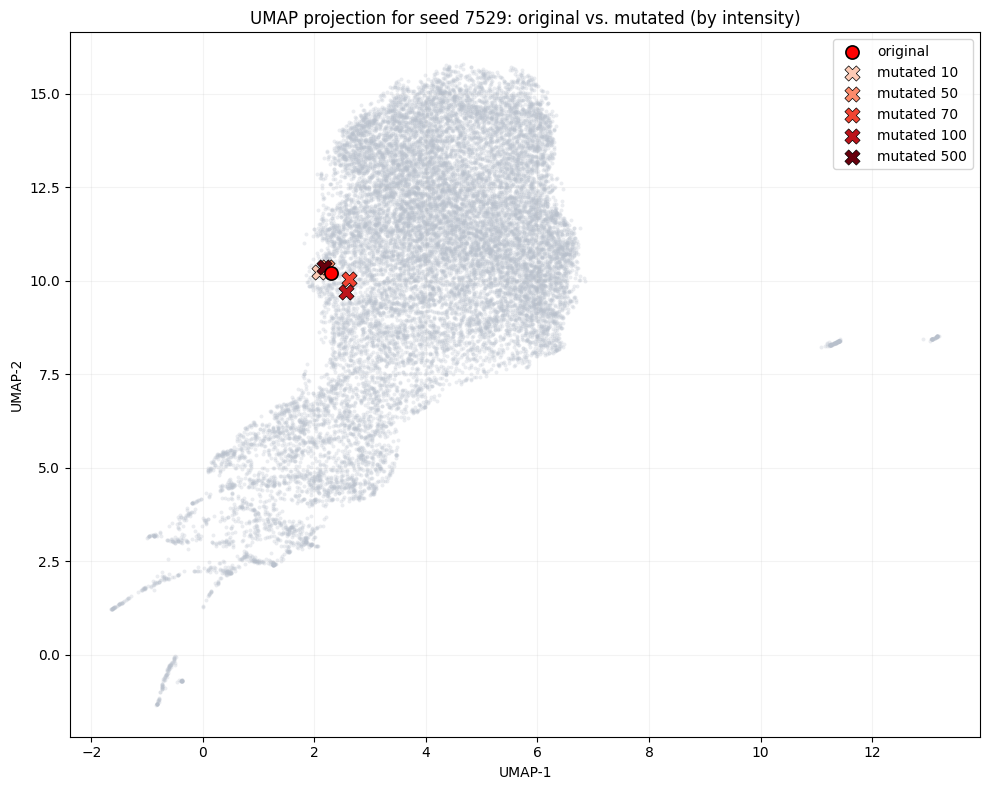

Original_embedding: [[ 0.51210904 -0.05922209  1.1793563   0.08673919 -0.76992524 -0.37026978
  -1.004844   -0.6059661   0.63797474  0.31199923  0.32831055 -0.22511998
  -0.506714    1.3550601  -0.63948905  1.4305754  -0.15184408  0.58606845
  -0.1684354   0.23675047 -0.06591263 -1.8489898   0.14972013  0.2293639
   0.8080007  -0.21792594 -0.08982696 -1.3922491   0.50179374  0.3020723
   0.15771922 -1.627248  ]]
Mutated_embedding_2: None
Mutated_embedding_10: [[ 0.5754502  -0.08697896  1.4390557  -0.14758676 -0.77445453 -0.2482953
  -0.8754891  -0.7196964   0.43319064  0.59195596  0.2166163  -0.01855367
  -0.6552068   1.2694522  -0.62343395  1.3662796  -0.17409459  0.37476456
  -0.20364916 -0.04771973 -0.42112806 -1.7321949   0.26562762  0.38528183
   0.7796837  -0.29109743 -0.31468812 -1.3290077   0.49087715  0.6515786
   0.12823509 -1.6129633 ]]
Mutated_embedding_50: [[ 0.26497704  0.33549038  1.1084955  -0.4555691  -1.0336162  -0.25006345
  -0.8297392  -0.2055175   1.0227164  -0.139

C:\Users\milob\AppData\Local\Temp\ipykernel_24284\931951594.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Reds", len(intensities))


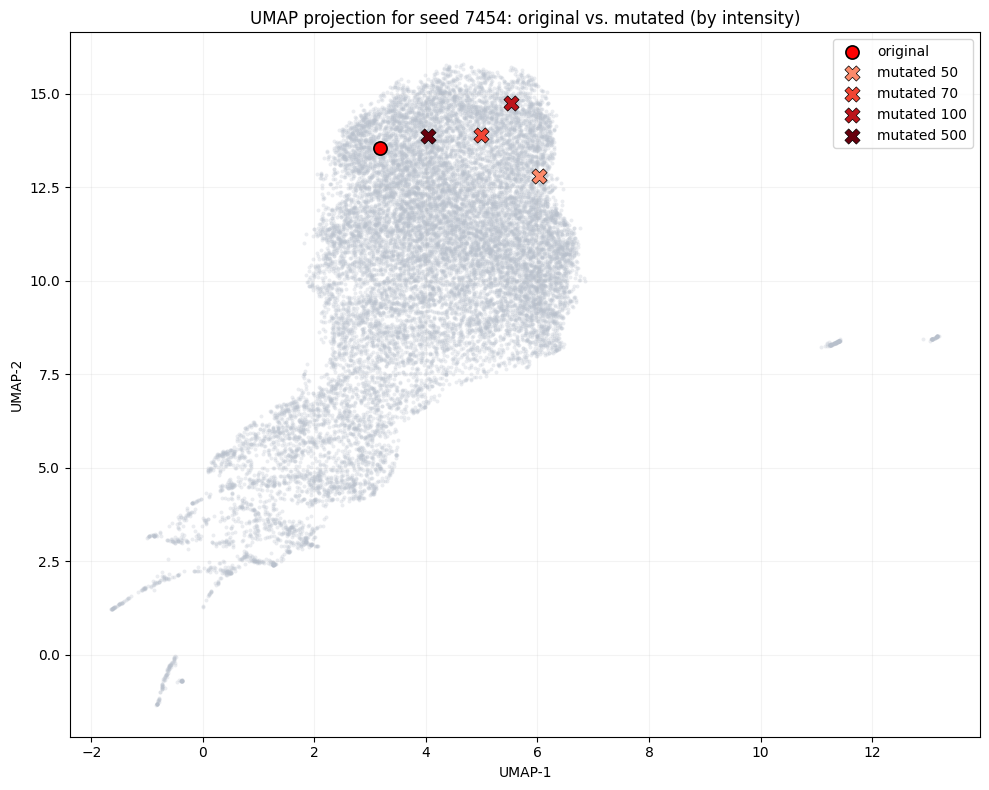

Original_embedding: [[-0.3077541   0.27862558 -0.82733965 -0.35378075 -0.41112977  0.33718947
   0.20652783 -0.5438645  -0.3472446   0.03946949  0.44241554  0.15035713
  -1.0912802   0.45090008 -0.13292675  0.7240131  -0.5446866   0.16604924
  -2.3463633   0.525856    0.05672383 -0.26414958 -0.11824196 -0.4605934
  -0.78910685  0.40174517  0.13272542  0.6140744  -0.70860636 -0.49262822
   0.3182869  -0.14152272]]
Mutated_embedding_2: None
Mutated_embedding_10: None
Mutated_embedding_50: [[-0.193194    0.0760128  -0.35052803 -0.11789297 -0.17012045 -0.20466304
  -0.45002896 -1.0804112  -0.59541965  0.1818665   0.2958006   0.5758869
  -0.36746594  0.4464295  -0.05201434  0.24663651 -0.17378576 -0.32818803
  -1.1477948  -0.06144585 -0.47978726  0.11176958 -0.6880286   0.5438808
   0.25417358 -0.14839357  0.52562296 -0.0157883  -0.04847423  0.63351625
  -0.20844683 -0.12683628]]
Mutated_embedding_70: [[-0.69045407  0.0366345  -0.21298456 -0.13046068 -0.31201777 -0.22318956
  -1.0955215  -0

In [3]:
import matplotlib.pyplot as plt
from mapelite.evaluator import EvaluatorMetrics

evaluator = EvaluatorMetrics.load_pretrained(EMBEDDING_MODEL_PATH)

def _convert_metrics_to_embedding(metrics_data):
    """Convert raw metric data to VAE embedding."""
    if not metrics_data or len(metrics_data) == 0:
        return None
    metrics_array = np.array(metrics_data)
    embedding = evaluator.measure_from_metrics(metrics_array)
    return np.asarray(embedding).reshape(1, -1)

for seed, payload in results_by_seed.items():
    intensities = payload["intensities"]
    original_embedding = _convert_metrics_to_embedding(payload["original_embedding_data"])

    mutated_embeddings_by_intensity = {
        intensity: _convert_metrics_to_embedding(metrics)
        for intensity, metrics in payload["mutated_embedding_data_by_intensity"].items()
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(
        umap_model.embedding_[:, 0],
        umap_model.embedding_[:, 1],
        s=8,
        c="#b8c0cc",
        alpha=0.28,
        linewidths=0,
        label="_embeddings background",
    )

    legend_handles = []
    legend_labels = []
    if original_embedding is not None:
        original_umap = umap_model.transform(original_embedding)
        original_handle = ax.scatter(
            original_umap[:, 0],
            original_umap[:, 1],
            s=90,
            c="#ff0000",
            edgecolors="black",
            linewidths=1.2,
            label="original",
            zorder=4,
        )
        legend_handles.append(original_handle)
        legend_labels.append("original")

    cmap = plt.cm.get_cmap("Reds", len(intensities))
    mutated_handles = {}
    for idx, intensity in enumerate(intensities):
        embedding = mutated_embeddings_by_intensity.get(intensity)
        if embedding is None:
            continue
        color = cmap(idx)
        mutated_umap = umap_model.transform(embedding)
        mutated_handles[intensity] = ax.scatter(
            mutated_umap[:, 0],
            mutated_umap[:, 1],
            s=120,
            c=[color],
            marker="X",
            edgecolors="black",
            linewidths=0.5,
            label=f"mutated {intensity}",
            zorder=3,
        )

    for intensity in intensities:
        handle = mutated_handles.get(intensity)
        if handle is None:
            continue
        legend_handles.append(handle)
        legend_labels.append(f"mutated {intensity}")

    ax.set_title(f"UMAP projection for seed {seed}: original vs. mutated (by intensity)")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(legend_handles, legend_labels, frameon=True)
    ax.grid(alpha=0.15)
    plt.tight_layout()
    plt.show()

    print("Original_embedding:", original_embedding)
    for intensity in intensities:
        print(f"Mutated_embedding_{intensity}:", mutated_embeddings_by_intensity.get(intensity))

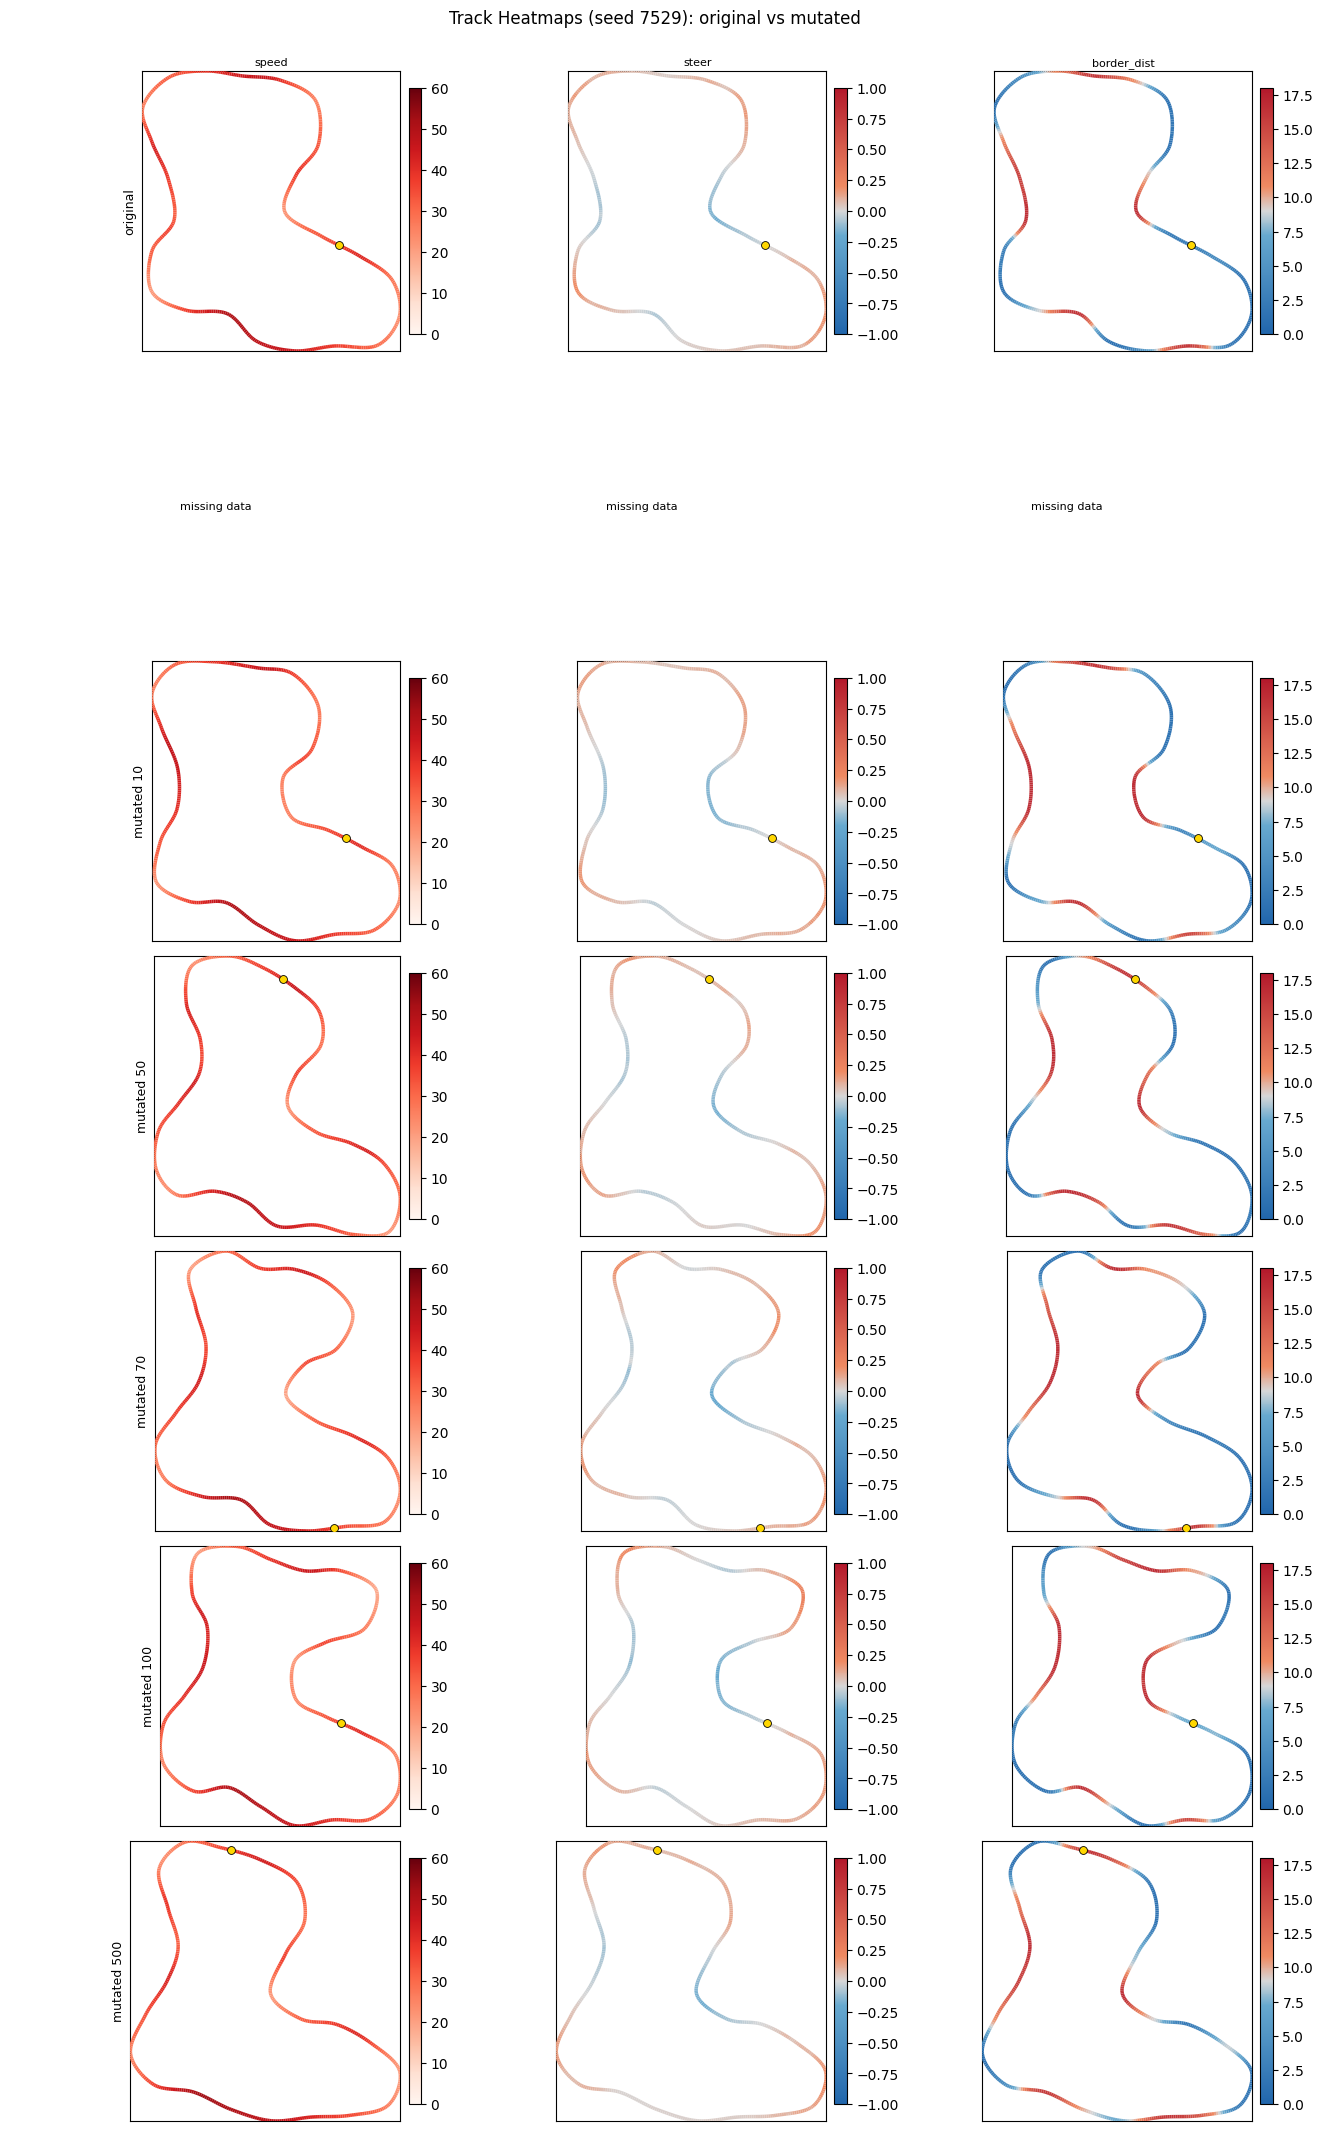

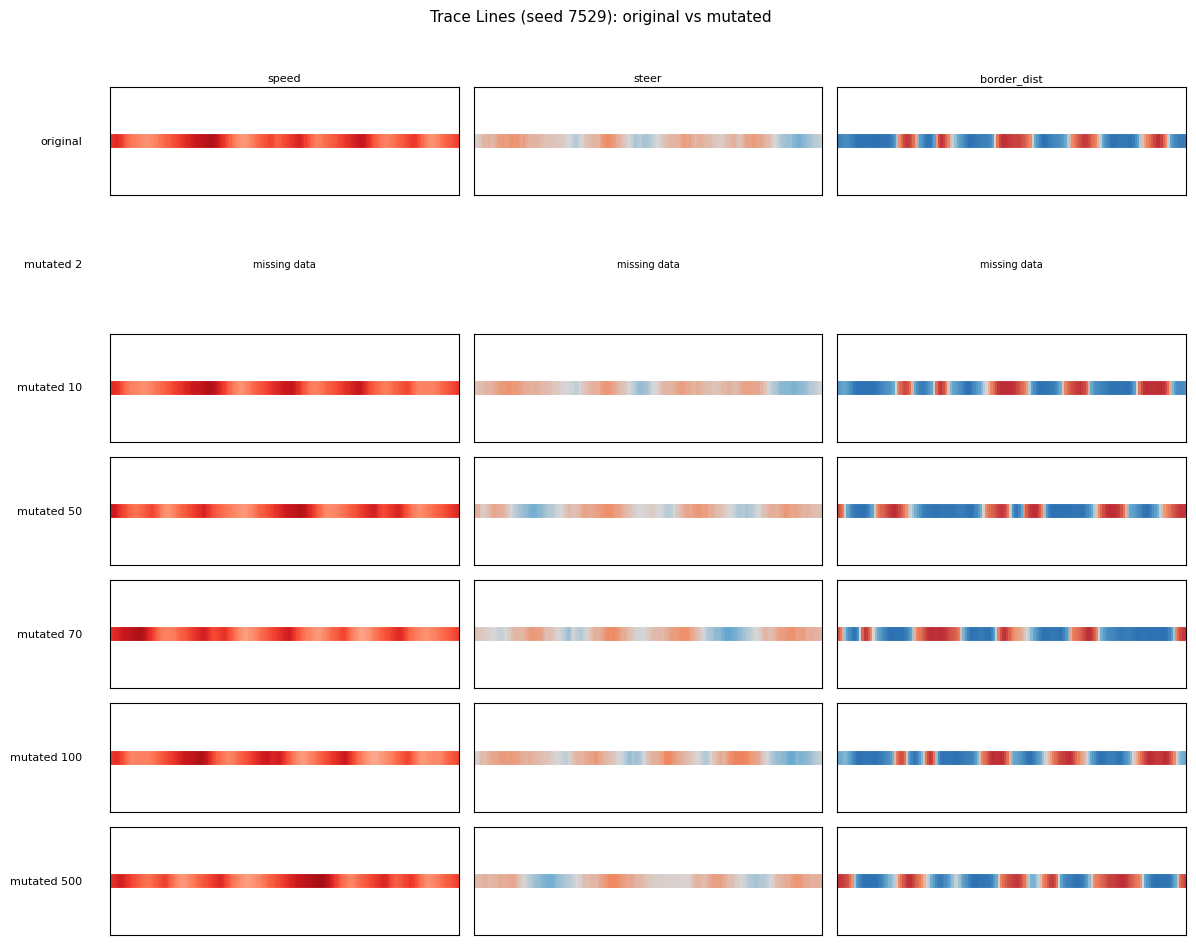

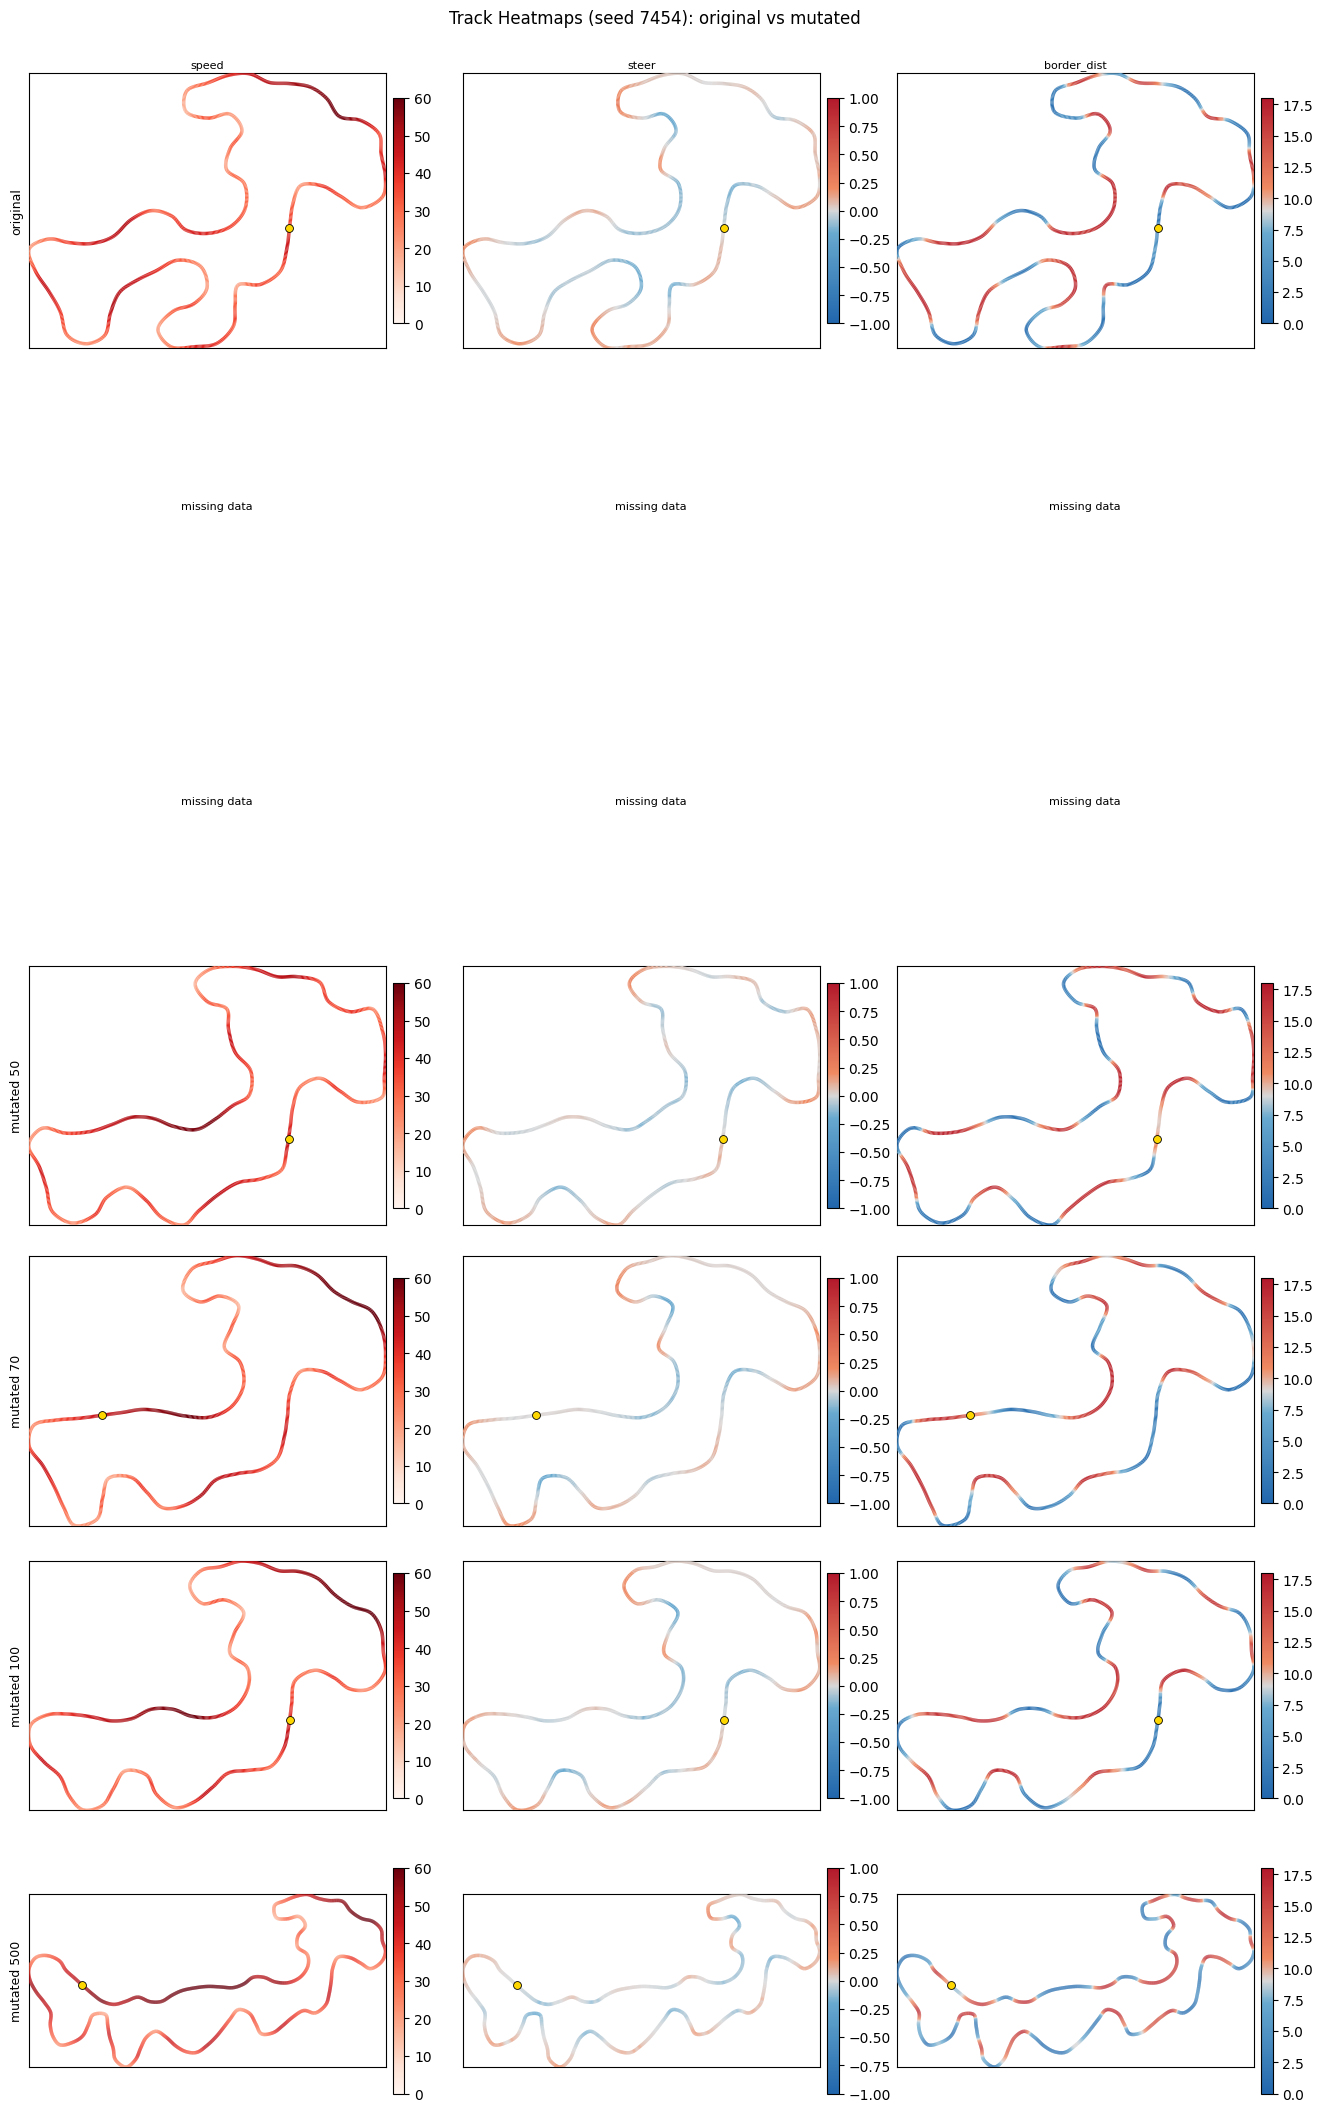

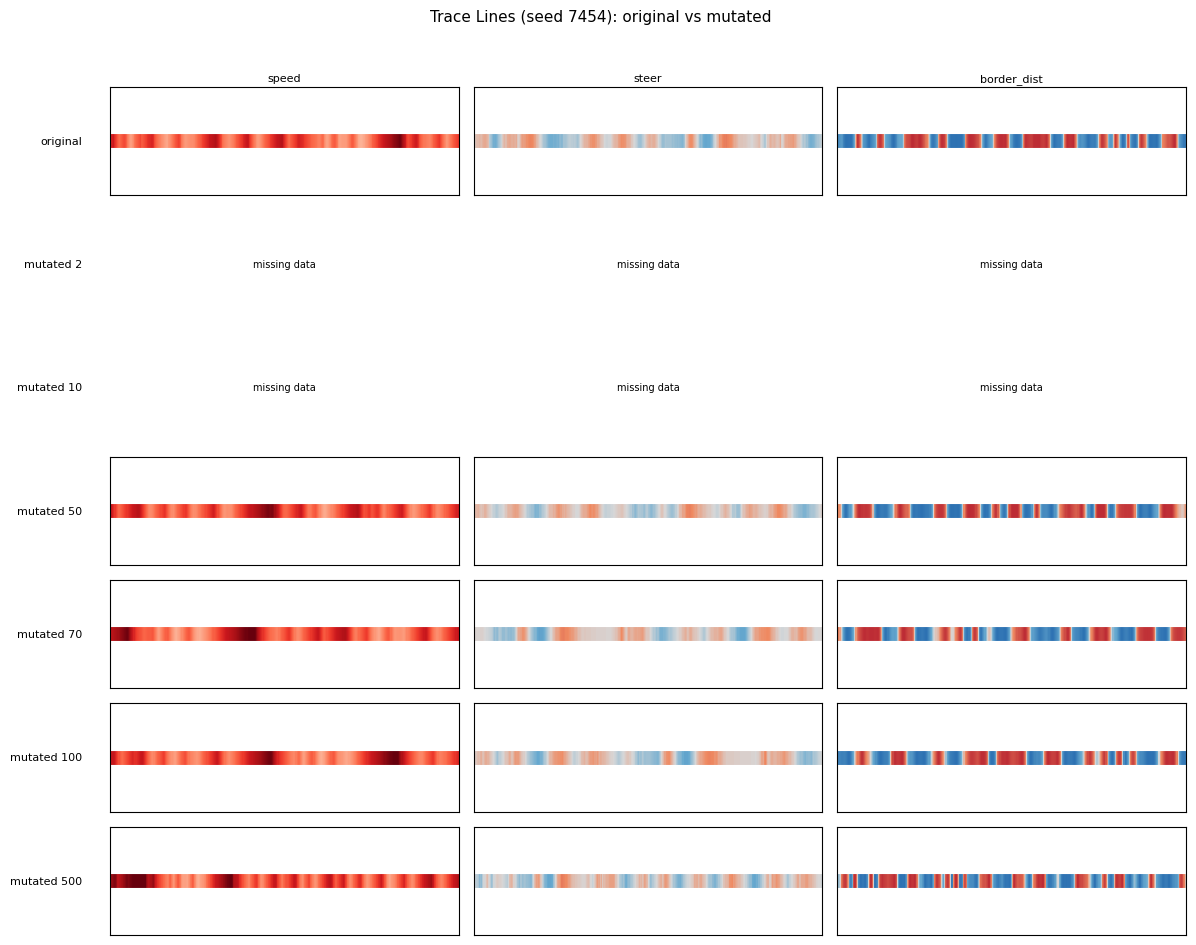

In [4]:
import math
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import mapelite.data_analysis.utils as analysis_utils
importlib.reload(analysis_utils)

from mapelite.data_analysis.utils import (
    plot_track,
    plot_track_heatmap,
    plot_trace_fixed_line,
)

HEATMAP_METRICS = ["speed_trace", "steer_trace", "border_dist_trace"]
HEATMAP_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "accel_trace": (0, 1),
    "brake_trace": (0, 1),
    "border_dist_trace": (0, 18),
}

CUSTOM_BURD = LinearSegmentedColormap.from_list(
    "custom_burd",
    [
        (0.0, (33 / 255.0, 102 / 255.0, 172 / 255.0)),
        (0.4, (103 / 255.0, 169 / 255.0, 207 / 255.0)),
        (0.5, (215 / 255.0, 215 / 255.0, 215 / 255.0)),
        (0.6, (239 / 255.0, 138 / 255.0, 98 / 255.0)),
        (1.0, (178 / 255.0, 24 / 255.0, 43 / 255.0)),
    ],
    N=256,
)

HEATMAP_CMAPS = {
    "speed_trace": "Reds",
    "accel_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "brake_trace": "Reds",
    "border_dist_trace": CUSTOM_BURD,
}

LINE_METRICS = ["speed_trace", "steer_trace", "border_dist_trace"]
LINE_RANGES = {
    "speed_trace": (0, 60),
    "steer_trace": (-1, 1),
    "border_dist_trace": (0, 18),
}
LINE_CMAPS = {
    "speed_trace": "Reds",
    "steer_trace": CUSTOM_BURD,
    "border_dist_trace": CUSTOM_BURD,
}

def _clean_trace(trace):
    if not trace:
        return []
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return []
    values = arr[:, 0]
    distances = arr[:, 1]
    finite = np.isfinite(values) & np.isfinite(distances)
    values, distances = values[finite], distances[finite]
    if len(values) < 2:
        return []
    return list(zip(values.tolist(), distances.tolist()))

def _extract_trace_values(trace):
    if not trace:
        return np.array([])
    arr = np.asarray(trace, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 1:
        return np.array([])
    values = arr[:, 0]
    values = values[np.isfinite(values)]
    return values

def _plot_start_point(ax, track):
    if not track:
        return
    start = track[0]
    sx, sy = start.get("x"), start.get("y")
    if sx is None or sy is None:
        return
    ax.scatter(
        [sx],
        [sy],
        s=32,
        c="gold",
        edgecolors="black",
        linewidths=0.6,
        zorder=10,
        marker="o",
    )

for seed, payload in results_by_seed.items():
    intensities = payload["intensities"]
    items = [("original", payload["original_track"], payload["original_traces"])]
    for intensity in intensities:
        items.append(
            (
                f"mutated {intensity}",
                payload["mutated_tracks_by_intensity"].get(intensity),
                payload["mutated_traces_by_intensity"].get(intensity, {}),
            )
        )

    if len(items) == 0:
        print(f"No track data found for seed {seed}. Run Cell 2 first.")
        continue

    # Heatmaps over track geometry
    nrows = len(items)
    ncols = len(HEATMAP_METRICS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 3.1 * nrows),
        squeeze=False,
    )

    for r, (label, track, traces) in enumerate(items):
        for c, metric in enumerate(HEATMAP_METRICS):
            ax = axes[r, c]
            metric_trace = _clean_trace((traces or {}).get(metric))
            metric_label = metric.replace("_trace", "")

            if track and metric_trace:
                plot_track_heatmap(
                    ax,
                    track,
                    metric_trace,
                    title=metric_label if r == 0 else None,
                    cmap=HEATMAP_CMAPS.get(metric, "Reds"),
                    color_range=HEATMAP_RANGES.get(metric),
                )
                _plot_start_point(ax, track)
            else:
                if track:
                    plot_track(ax, track, title=metric_label if r == 0 else None, track_color="lightgray")
                    _plot_start_point(ax, track)
                else:
                    ax.set_axis_off()
                ax.text(
                    0.5,
                    0.5,
                    "missing data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=8,
                )

            if c == 0:
                ax.set_ylabel(label, fontsize=9)

    fig.suptitle(f"Track Heatmaps (seed {seed}): original vs mutated", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # Linear trace summary
    ncols = len(LINE_METRICS)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 1.2 * nrows + 1.2),
        squeeze=False,
    )

    for r, (label, _track, traces) in enumerate(items):
        for c, metric in enumerate(LINE_METRICS):
            ax = axes[r, c]
            values = _extract_trace_values((traces or {}).get(metric))
            title = metric.replace("_trace", "")
            if values.size >= 2:
                plot_trace_fixed_line(
                    ax,
                    values,
                    line_length=1.0,
                    y=0.0,
                    title=title if r == 0 else None,
                    cmap=LINE_CMAPS.get(metric, "Reds"),
                    color_range=LINE_RANGES.get(metric),
                    linewidth=10,
                    show_colorbar=False,
                )
            else:
                ax.set_axis_off()
                if r == 0:
                    ax.set_title(title, fontsize=8, pad=4)
                ax.text(
                    0.5,
                    0.5,
                    "missing data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=7,
                )

            if c == 0:
                ax.text(
                    -0.08,
                    0.5,
                    label,
                    transform=ax.transAxes,
                    ha="right",
                    va="center",
                    fontsize=8,
                )

    fig.suptitle(f"Trace Lines (seed {seed}): original vs mutated", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()